# Preprocess MUG

In [1]:
import tensorflow as tf

import os
from pathlib import Path
import time
import datetime
import numpy as np
import cv2
import hashlib

from matplotlib import pyplot as plt
from IPython import display
from tqdm.notebook import tqdm

2023-04-14 13:47:53.701779: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2023-04-14 13:47:54.289743: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-04-14 13:47:56.851743: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2023-04-14 13:47:56.882842: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-04-14 13:48:04.484381: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not fin

In [17]:
def plot_sample_sequence(sample_sequence):
    plot_sequence = list(sample_sequence)
    n_frames = len(plot_sequence)
    rows = ((n_frames-1) // 10)+1
    cols = max(n_frames % 10, 10)
    fig = plt.figure(figsize=(20, 4))
    for i, im in enumerate(plot_sequence):
        ax = fig.add_subplot(rows,cols,i+1)
        ax.imshow(im) 
        ax.axis('off')
    plt.show()
    plt.close()

def sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[0]):
        yield sample_sequence[i, ...]

def plot_sequence(sample_sequence):
    plot_sample_sequence(sequence_generator(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def inverse_sequence_generator(sample_sequence):
    for i in range(sample_sequence.shape[-1]):
        yield sample_sequence[..., i]

def plot_inverse_sequence(sample_sequence):
    plot_sample_sequence(inverse_sequence_generator(sample_sequence))

def plot_normalized_inverse_sequence(sample_sequence):
    plot_inverse_sequence(normalized_sequence_to_images(sample_sequence))

def plot_normalized_sequence(sample_sequence):
    plot_sequence(normalized_sequence_to_images(sample_sequence))

def plot_sequence_from_tensor(sample_sequence):
    if len(sample_sequence.shape) == 5 and sample_sequence.shape[0] == 1:
        plot_sequence(sample_sequence[0])
    else:
        raise ValueError("The tensor must be of shape (1, frames, height, width, channels)")

def plot_sequence_from_normalized_tensor(sample_sequence):
    plot_sequence_from_tensor(normalized_sequence_to_images(sample_sequence))

In [10]:
# TODO: video path to hash

def repeat_last_frame_to_fill(video, n):
    if len(video) < n:
        video = np.concatenate([video, np.repeat(video[-1:], n-len(video), axis=0)], axis=0) # TODO: check axis
    return video

def get_clip_path(folder, video_number, clip_number):
    return  folder / f"{video_number}" / f"{clip_number}.npy"

def load_clip(cap, n=None):
    if n is None:
        n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    return np.array([cap.read()[1] for i in range(n)])

# TODO: check if file exist from hash
# TODO: this function suposes if it is the same path is the exact same video
def load_video(path, clip_size=20):
    cap = cv2.VideoCapture(str(path))
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    clips = []
    video = load_clip(cap, n)
    if n > 20: 
        # split video into 20 frame chunks
        for i in range(0, n, clip_size):
            current_clip = video[i:i+clip_size]
            if len(current_clip) < clip_size:
                current_clip = repeat_last_frame_to_fill(current_clip, clip_size)
            clips.append(video[i:i+clip_size])
    else:
        clips.append(repeat_last_frame_to_fill(video, clip_size))
    return clips

# resize video lanczos4
def resize_video(video, size=64):
    resized = []
    for frame in video:
        if frame is not None:
            resized.append(cv2.resize(frame, (size,size), interpolation=cv2.INTER_LANCZOS4))
    return resized

# BRG to RGB
def bgr_to_rgb(video):
    return np.array([cv2.cvtColor(frame, cv2.COLOR_BGR2RGB) for frame in video])

def save_video(video, path, video_number):
    for i, clip in enumerate(video):
        clip_path = get_clip_path(path, video_number, i)
        clip_path.parent.mkdir(parents=True, exist_ok=True)
        np.save(str(clip_path), clip)
        
# load videos from npy
def load_videos(videos_paths, n=None):
    videos_paths = list(videos_paths)
    if n is None:
        n = len(videos_paths)
    else:
        videos_paths = videos_paths[:n]
    videos = []
    for path in tqdm(videos_paths, total=n):
        clip = np.load(path)
        if len(clip) == 20:
            videos.append(np.load(path))
    return np.array(videos, dtype=np.float32)

def process_videos(videos_paths, save_path):
    videos_paths = list(videos_paths)
    n = len(videos_paths)
    for i, video_path in tqdm(enumerate(videos_paths), total=n):
        video = load_video(video_path)
        clips = np.array(list(map(resize_video, video)))
        clips = np.array(list(map(bgr_to_rgb, clips)))
        save_video(clips, save_path, i)


In [7]:
mug_path = Path('../data/mug/')
save_path = Path('../data/').resolve() / 'mug_clips'
process_videos(list(mug_path.glob('**/*.avi')), save_path)

  0%|          | 0/1033 [00:00<?, ?it/s]

/tmp/ipykernel_1286110/2238745645.py:69: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  clips = np.array(list(map(resize_video, video)))
/tmp/ipykernel_1286110/2238745645.py:70: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  clips = np.array(list(map(bgr_to_rgb, clips)))
/tmp/ipykernel_1286110/2238745645.py:14: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when c

In [11]:
sequences = load_videos(save_path.glob('**/*.npy'))
print(sequences.shape)

  0%|          | 0/7426 [00:00<?, ?it/s]

(6471, 20, 64, 64, 3)


(20, 64, 64, 3)


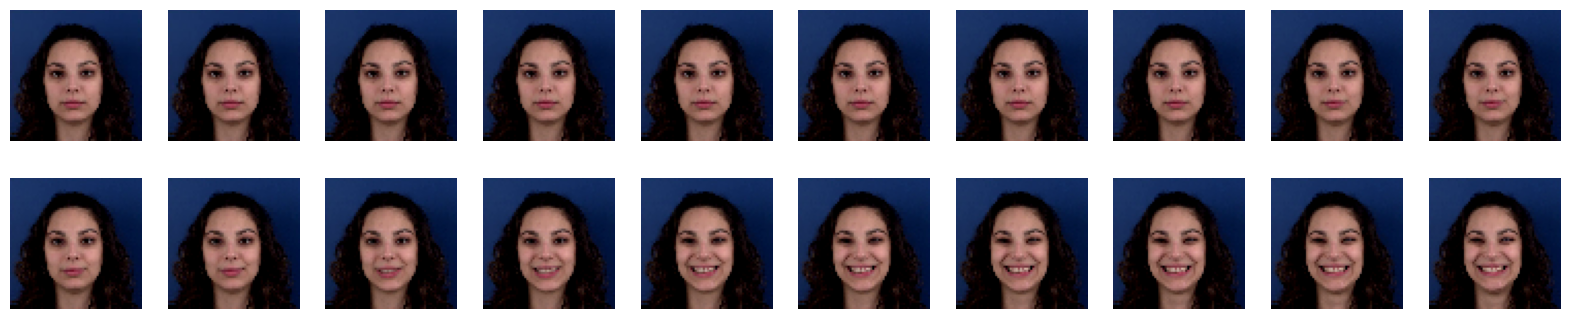

tf.Tensor(0, shape=(), dtype=int32)


In [21]:
sample_sequence = tf.cast(sequences[0,...], tf.int32)
print(sample_sequence.shape)
plot_sequence(sample_sequence)